## Notebook: Online Shoppers Purchasing Intention - EDA & Modelling

### Goals : Construire un modele prédictif qui détermine si un visiteur achètera (Revenue=True) ou pas (Revenue=False) à partir du dataset Online Shoppers Purchasing Intention Dataset (UCI ID 468).

    I) Faire une analyse Exploaratoire (EDA = Exploratory Data Analysis)
        1. https://docs.aws.amazon.com/sagemaker/latest/dg/canvas-analyses.html
        2. https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees

    II) Construire un modele de machine learning 
        1. https://www.machinelearningplus.com/machine-learning/exploratory-data-analysis-eda/
        2. https://docs.aws.amazon.com/prescriptive-guidance/latest/ml-production-ready-pipelines/step1.html
        3. https://cloud.google.com/blog/products/ai-machine-learning/building-ml-models-with-eda-feature-selection?hl=en

In [ ]:
!pip install ucimlrepo

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo, list_available_datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# you can verify if your dataset exist in the list
list_available_datasets(search='online shoppers purchasing intention')

---------------------------------------------------------------------------------------------
The following datasets are available for search query "online shoppers purchasing intention":
---------------------------------------------------------------------------------------------
Dataset Name                                    ID    
------------                                    --    
Online Shoppers Purchasing Intention Dataset    468   



In [16]:
# --- Load dataset (UCI ID 468) ---
ospid = fetch_ucirepo(id=468) # ospid = Online Shoppers Purchasing Intention Dataset
# dataset with all columns
df = ospid.data.original.copy()
print("shape:", df.shape)
print("Columns:", df.columns.tolist())

shape: (12330, 18)
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [ ]:
# head
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# if you want to check the features and target
# XX = ospid.data.features 
# yy = ospid.data.targets 
# yy

,Revenue
0,False
1,False
2,False
3,False
4,False
...,...
12325,False
12326,False
12327,False
12328,False


In [22]:
# Check target distribution
print("\nTarget (Revenue) value counts:")
print(df['Revenue'].value_counts(dropna=False))

df['Revenue'] = df['Revenue'].astype(bool)  # True/False -> bool


Target (Revenue) value counts:
Revenue
False    10422
True      1908
Name: count, dtype: int64


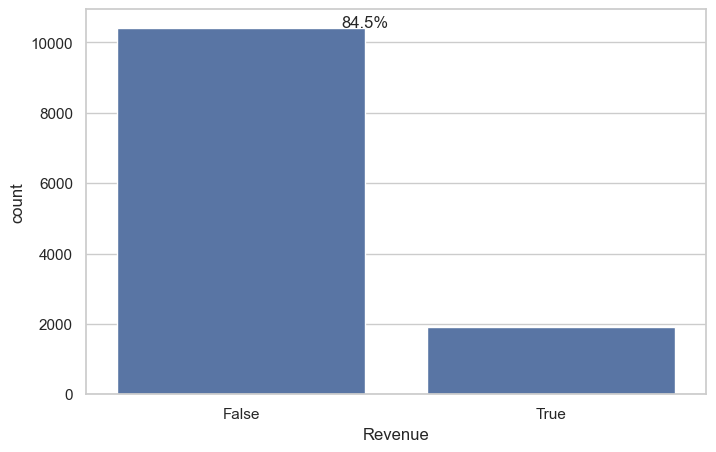

In [ ]:
"""
# --- EDA : Percentage of customers have brought Revenue. 
‘True’ means customer has bought the product and ‘False’ means customer didnot buy the product.
"""
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
total = float(len(df))
ax = sns.countplot(x="Revenue", data=df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center')
    plt.show()

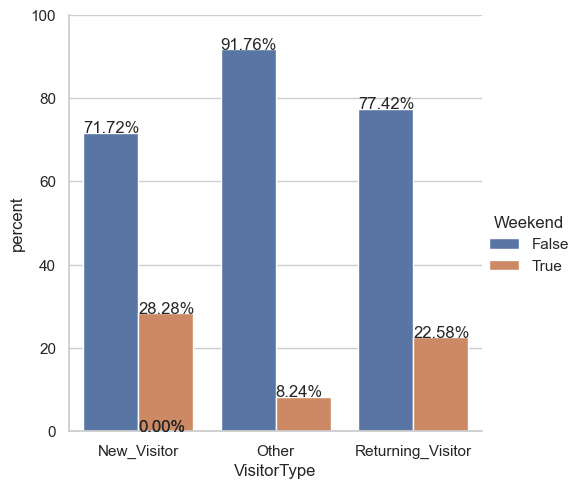

In [85]:
"""
# --- EDA : Percentage distribution of ‘VisitorType’ over the ‘Weekend’
"""
import pprint
x,y = 'VisitorType', 'Weekend'
df1 = df.groupby(x)[y].value_counts(normalize=True)
df1 = df1.mul(100)
df1 = df1.rename('percent').reset_index()
g = sns.catplot(x=x,y='percent',hue=y,kind='bar',data=df1)
g.ax.set_ylim(0,100)
for p in g.ax.patches:
    txt = f"{p.get_height():.2f}%"
    txt_x = p.get_x()
    txt_y = p.get_height()
    g.ax.text(txt_x, txt_y, txt)

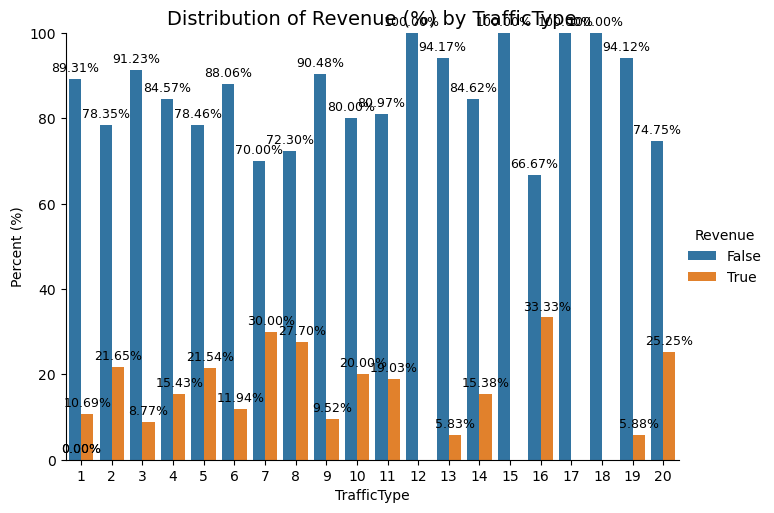

In [ ]:
"""
# --- EDA : Distribution of Revenue (%) by TrafficType
"""
x, y = 'TrafficType', 'Revenue'
# compute percent distribution for each TrafficType and Revenue value
df1 = df.groupby(x)[y].value_counts(normalize=True).mul(100).rename('percent').reset_index()

# plot with seaborn catplot (bar)
g = sns.catplot(x=x, y='percent', hue=y, kind='bar', data=df1, height=5, aspect=1.4)
g.ax.set_ylim(0, 100)
g.ax.set_title("Distribution of Revenue (%) by TrafficType", fontsize=14)
g.ax.set_ylabel("Percent (%)")

# Annotate bars 
for p in g.ax.patches:
    x_coord = p.get_x() + p.get_width() / 2 # get center of bar for x text placement
    y_coord = p.get_height()
    txt = f"{p.get_height():.2f}%"
    g.ax.text(x_coord, y_coord + 1.0, txt, ha='center', va='bottom', fontsize=9)

plt.show()

In [ ]:
# /!\ Tu peux rajouter d'autres plot pour mieux comprendre tes donnees /!\

In [24]:
# --- Data preprocessing  ---
# Split features/target
target_col = 'Revenue'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # models expect 0/1

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# Preprocessing pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

Numeric cols: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Categorical cols: ['Month', 'VisitorType', 'Weekend']


In [ ]:
# --- Train/test split (75% - 25%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


# --- Model pipelines ---
pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=2000))
])

pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fit models
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

Train shape: (9247, 17) Test shape: (3083, 17)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Month', 'VisitorType',
                                                   'Weekend'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [72]:
# --- Evaluation ---
def evaluate_model(pipe, X_test, y_test, model_name="model", SHOW_METRICS=True):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None # ROC Curve
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    if SHOW_METRICS:
        print(f"=== {model_name} ===")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-score:  {f1:.4f}")
        if auc is not None:
            print(f"ROC AUC:   {auc:.4f}")

        print("Confusion matrix:")
        print(cm)

    # ROC curve
    # if y_proba is not None:
    #     RocCurveDisplay.from_predictions(y_test, y_proba)
        # if SHOW_ROC:
        #     plt.title(f"ROC Curve - {model_name}")
        #     plt.show()

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc, cm=cm, y_proba=y_proba)


# Evaluate both models
res_lr = evaluate_model(pipe_lr, X_test, y_test, "Logistic Regression")
print('\n')
res_rf = evaluate_model(pipe_rf, X_test, y_test, "Random Forest")

=== Logistic Regression ===
Accuracy:  0.8780
Precision: 0.7149
Recall:    0.3522
F1-score:  0.4719
ROC AUC:   0.8866
Confusion matrix:
[[2539   67]
 [ 309  168]]


=== Random Forest ===
Accuracy:  0.8985
Precision: 0.7440
Recall:    0.5241
F1-score:  0.6150
ROC AUC:   0.9167
Confusion matrix:
[[2520   86]
 [ 227  250]]


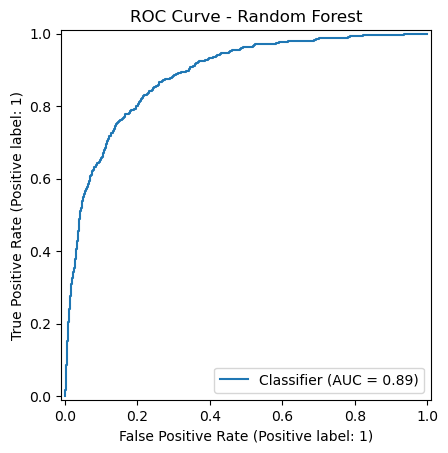

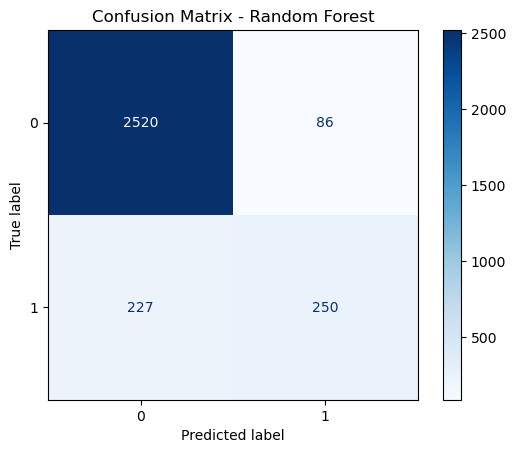

In [ ]:
# Random Forest visualisation
from sklearn.metrics import ConfusionMatrixDisplay

res_rf = evaluate_model(pipe_rf, X_test, y_test, "Random Forest", SHOW_METRICS=False)
auc_rf = res_rf['auc']
cm_rf = res_rf['cm']

# ROC curve
if res_lr['auc'] is not None:
    RocCurveDisplay.from_predictions(y_test, res_lr['y_proba'])
    plt.title("ROC Curve - Random Forest")
    plt.show()


# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()



Top 20 feature importances (Random Forest):


PageValues                       0.366455
ExitRates                        0.088819
ProductRelated_Duration          0.085756
ProductRelated                   0.071851
Administrative_Duration          0.057044
BounceRates                      0.054837
Administrative                   0.042428
Region                           0.030963
TrafficType                      0.030824
Informational_Duration           0.026018
Month_Nov                        0.019350
Browser                          0.019122
OperatingSystems                 0.017968
Informational                    0.017203
Weekend_False                    0.008172
Weekend_True                     0.007856
VisitorType_Returning_Visitor    0.007260
VisitorType_New_Visitor          0.007120
Month_May                        0.006889
Month_Dec                        0.005687
dtype: float64

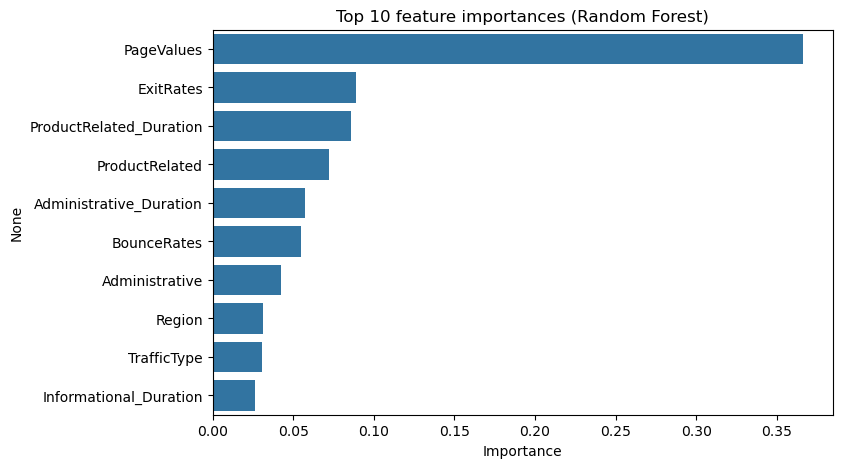

In [ ]:
# --- Feature importance (Random Forest) ---
# To get feature names after ColumnTransformer + OneHotEncoder
# 1) numeric names
num_features = num_cols
# 2) categorical OHE feature names (OHE = One Hot Encoder)
ohe = pipe_rf.named_steps['pre'].transformers_[1][1].named_steps['ohe']
cat_feature_names = []
if hasattr(ohe, 'get_feature_names_out'):
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
else:
    # fallback
    for col in cat_cols:
        unique_vals = X_train[col].astype(str).unique()
        cat_feature_names += [f"{col}_{v}" for v in unique_vals]

feature_names = num_features + cat_feature_names

# get importances
rf_clf = pipe_rf.named_steps['clf']
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# show top 20
print("\nTop 20 feature importances (Random Forest):")
display(feat_imp.head(20))

# barplot of top 10
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index)
plt.title("Top 10 feature importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [ ]:
"""
LA courbe ROC du modele Random Forest
Ici, elle montre comment le modele se comporte pour differents seuils de decision.
La ligne diagonale (de (0,0) à (1,1)) correspond à un modele au hasard (ex. si AUC = 0.5).
Plus la courbe est au-dessus de la diagonale, meilleur est le modele.

L’AUC de ce modele: AUC = 0.89 donc le modele est bon, mais on peut l'ameliorer si on veut (Tu peux essayer d'autres modeles 
comme XGBoost par exemple).
Il detecte bien les vrais positifs tout en gardant les faux positifs relativement bas.


====
Pour comparaison, si tu as
AUC = 1 ==> parfait
AUC = 0.5 ==> hasard
AUC < 0.5 ==> pire qu’un hasard, lol


Axes de la courbe
X-axis (FPR) : False Positive Rate 

0 = aucun faux positif
1 = tous les negatifs sont classes positifs

Y-axis (TPR) : True Positive Rate
0 = aucun vrai positif detectE
1 = tous les vrais positifs detectEs

"""